# Screenings Exploratory Data Analysis

## Purpose

This notebook checks the screening data. It checks missing values, IDs, dates, duplicate rows, and links to other files.

## Files used

- `Screenings.csv` — screening records
- `Participations.csv` — people registered for the programme
- `Programme_Services.csv` — services offered by the programme
- `Practitioners.csv` — practitioners who did the screenings

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

def find_raw_data_dir(start: Path = Path.cwd()) -> Path:
    for directory in (start, *start.parents):
        for candidate in (directory / 'data' / 'raw', directory / 'data-analytics' / 'data' / 'raw'):
            if candidate.is_dir():
                return candidate
    raise FileNotFoundError('Could not locate data-analytics/data/raw')

RAW_DATA_DIR = find_raw_data_dir()

## 1. Load the data

In [2]:
screenings = pd.read_csv(RAW_DATA_DIR / 'Screenings.csv')
participations = pd.read_csv(RAW_DATA_DIR / 'Participations.csv')
programme_services = pd.read_csv(RAW_DATA_DIR / 'Programme_Services.csv')
practitioners = pd.read_csv(RAW_DATA_DIR / 'Practitioners.csv')

pd.DataFrame({
    'dataset': ['Screenings', 'Participations', 'Programme Services', 'Practitioners'],
    'rows': [len(screenings), len(participations), len(programme_services), len(practitioners)],
    'columns': [len(screenings.columns), len(participations.columns), len(programme_services.columns), len(practitioners.columns)],
})

,dataset,rows,columns
0,Screenings,144,8
1,Participations,28,9
2,Programme Services,6,5
3,Practitioners,3,8


## 2. Check the file

In [3]:
screenings.head(10)

,screening_id,participation_id,programme_service_id,practitioner_id,screened_at,status,notes,created_at
0,SCR-0001,PAR-001,PS-001,PRA-002,2026-06-18T07:09:00Z,completed,NaN,2026-06-18T06:30:00Z
1,SCR-0002,PAR-001,PS-002,PRA-002,2026-06-18T07:13:00Z,completed,NaN,2026-06-18T06:30:00Z
2,SCR-0003,PAR-001,PS-003,PRA-002,2026-06-18T07:17:00Z,completed,NaN,2026-06-18T06:30:00Z
3,SCR-0004,PAR-001,PS-004,PRA-002,2026-06-18T07:21:00Z,completed,NaN,2026-06-18T06:30:00Z
4,SCR-0005,PAR-001,PS-005,PRA-002,2026-06-18T07:25:00Z,completed,NaN,2026-06-18T06:30:00Z
5,SCR-0006,PAR-001,PS-006,PRA-003,2026-06-18T07:29:00Z,completed,NaN,2026-06-18T06:30:00Z
6,SCR-0007,PAR-002,PS-001,PRA-001,2026-06-18T07:18:00Z,completed,NaN,2026-06-18T06:30:00Z
7,SCR-0008,PAR-002,PS-002,PRA-001,2026-06-18T07:22:00Z,completed,NaN,2026-06-18T06:30:00Z
8,SCR-0009,PAR-002,PS-003,PRA-001,2026-06-18T07:26:00Z,completed,NaN,2026-06-18T06:30:00Z
9,SCR-0010,PAR-002,PS-004,PRA-001,2026-06-18T07:30:00Z,completed,NaN,2026-06-18T06:30:00Z


In [4]:
screening_profile = pd.DataFrame({
    'data_type': screenings.dtypes.astype(str),
    'missing_count': screenings.isna().sum(),
    'missing_percent': screenings.isna().mean().mul(100).round(1),
    'unique_values': screenings.nunique(dropna=False),
})
screening_profile

,data_type,missing_count,missing_percent,unique_values
screening_id,object,0,0.0,144
participation_id,object,0,0.0,24
programme_service_id,object,0,0.0,6
practitioner_id,object,0,0.0,3
screened_at,object,0,0.0,144
status,object,0,0.0,1
notes,float64,144,100.0,1
created_at,object,0,0.0,1


In [5]:
required_columns = ['screening_id', 'participation_id', 'programme_service_id', 'practitioner_id', 'screened_at', 'status', 'created_at']
assert set(required_columns).issubset(screenings.columns)
assert screenings[required_columns].notna().all().all()
print('All required screening fields have values.')
print('The notes field is optional. Missing notes are allowed.')

All required screening fields have values.
The notes field is optional. Missing notes are allowed.


## 3. Check IDs and duplicate rows

In [6]:
id_checks = pd.Series({
    'duplicate_screening_ids': screenings['screening_id'].duplicated().sum(),
    'wrong_screening_id_format': (~screenings['screening_id'].str.match(r'^SCR-[0-9]{4}$', na=False)).sum(),
    'duplicate_participant_service_pairs': screenings.duplicated(['participation_id', 'programme_service_id']).sum(),
    'exact_duplicate_rows': screenings.duplicated().sum(),
})
id_checks.to_frame('count')

,count
duplicate_screening_ids,0
wrong_screening_id_format,0
duplicate_participant_service_pairs,0
exact_duplicate_rows,0


In [7]:
assert id_checks.eq(0).all()
print('Screening IDs are unique and correctly formatted.')
print('No person has the same service screening more than once.')

Screening IDs are unique and correctly formatted.
No person has the same service screening more than once.


## 4. Check links to other files

In [8]:
link_checks = pd.Series({
    'unknown_participation_ids': len(set(screenings['participation_id']) - set(participations['participation_id'])),
    'unknown_programme_service_ids': len(set(screenings['programme_service_id']) - set(programme_services['programme_service_id'])),
    'unknown_practitioner_ids': len(set(screenings['practitioner_id']) - set(practitioners['practitioner_id'])),
})
link_checks.to_frame('count')

,count
unknown_participation_ids,0
unknown_programme_service_ids,0
unknown_practitioner_ids,0


In [9]:
assert link_checks.eq(0).all()
print('All screenings link to known people, services, and practitioners.')

All screenings link to known people, services, and practitioners.


## 5. Check dates

In [10]:
screening_times = screenings.merge(
    participations[['participation_id', 'checked_in_at']],
    on='participation_id', how='left', validate='many_to_one',
)
for column in ['checked_in_at', 'screened_at', 'created_at']:
    screening_times[column] = pd.to_datetime(screening_times[column], utc=True, errors='coerce')

date_checks = pd.Series({
    'bad_screened_dates': screening_times['screened_at'].isna().sum(),
    'bad_created_dates': screening_times['created_at'].isna().sum(),
    'screened_before_check_in': (screening_times['screened_at'] < screening_times['checked_in_at']).sum(),
    'created_after_screening': (screening_times['created_at'] > screening_times['screened_at']).sum(),
})
date_checks.to_frame('count')

,count
bad_screened_dates,0
bad_created_dates,0
screened_before_check_in,0
created_after_screening,0


In [11]:
assert date_checks.eq(0).all()
print('All screening dates are valid and follow the right order.')

All screening dates are valid and follow the right order.


## 6. Check screening coverage

In [12]:
screenings_per_person = screenings.groupby('participation_id').size().rename('screening_count')
coverage = participations[['participation_id', 'attendance_status']].join(screenings_per_person, on='participation_id').fillna({'screening_count': 0})
coverage['screening_count'] = coverage['screening_count'].astype(int)
coverage.groupby(['attendance_status', 'screening_count']).size().rename('people').reset_index()

,attendance_status,screening_count,people
0,absent,0,2
1,attended,6,24
2,registered,0,2


In [13]:
assert coverage.loc[coverage['attendance_status'] == 'attended', 'screening_count'].eq(len(programme_services)).all()
assert coverage.loc[coverage['attendance_status'] != 'attended', 'screening_count'].eq(0).all()
print('Every attendee has all 6 screenings.')
print('People who did not attend have no screenings.')

Every attendee has all 6 screenings.
People who did not attend have no screenings.


## 7. Look at services and practitioners

In [14]:
service_counts = screenings['programme_service_id'].value_counts().sort_index()
practitioner_counts = screenings['practitioner_id'].value_counts().sort_index()
display(service_counts.to_frame('screening_count'))
display(practitioner_counts.to_frame('screening_count'))

,screening_count
programme_service_id,
PS-001,24
PS-002,24
PS-003,24
PS-004,24
PS-005,24
PS-006,24


,screening_count
practitioner_id,
PRA-001,60
PRA-002,60
PRA-003,24


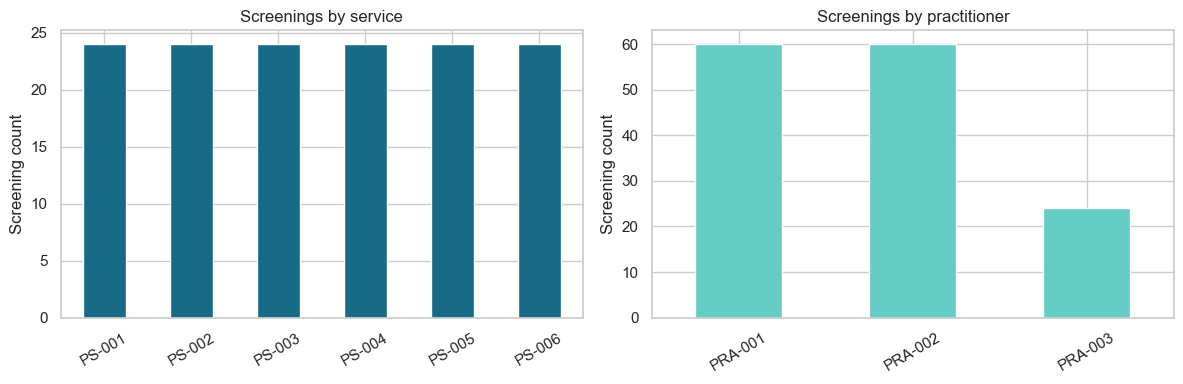

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
service_counts.plot(kind='bar', ax=axes[0], color='#176B87', title='Screenings by service')
practitioner_counts.plot(kind='bar', ax=axes[1], color='#64CCC5', title='Screenings by practitioner')
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('Screening count')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 8. Findings

There are 144 screening rows. Every screening ID is unique. All required fields have values. The notes field is empty in every row, but notes are optional.

All screenings are complete. All screenings link to a known participant, programme service, and practitioner. All dates are valid.

There are 24 attendees. Each attendee has all 6 services, which gives 144 screenings. The 4 people who did not attend have no screenings.

Each service has 24 screenings. Two practitioners have 60 screenings each. One practitioner has 24 screenings. These numbers show activity only. They do not show quality or performance.

## Next steps

- Keep the ID, date, duplicate, and link checks.
- Add notes only when there is useful information to record.
- Add more programmes before looking for trends.
- Use outcome data before comparing practitioner performance.